# Duc Huy Nguyen - Statistics DRP Project Autumn 2025
## Relationship between Job Postings and Unemployment
### with related Economics metrics

We first import the required libraries for the project

In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.interpolate import CubicSpline

import statsmodels.api as sm
# Import some ML models and tools from scikit_learn
from sklearn.metrics import (root_mean_squared_error, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC

# Use external library to plot our decision regions
from mlxtend.plotting import plot_decision_regions


In [145]:
# Suppress irrelevant warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="KNOWN BUG: p-values computed in this summary are likely much smaller than they should be.",
    category=UserWarning
)

## Loading data and preliminary processing
We then load relevant datasets on job postings, unemployment, interest rates, inflation, stock prices and GDP into our notebook.

In [146]:
natural_unemp_df = pd.read_csv('Data/quarterly_natural_unemp.csv')
unemp_df = pd.read_csv('Data/monthly_unemployment_rate.csv') # Read Unemployment data
cpi_df = pd.read_csv('Data/monthly_cpi.csv') # Read CPI data
gdp_df = pd.read_csv('Data/quarterly_gdp.csv')# Read GDP data
job_df = pd.read_csv('Data/monthly_job_postings.csv')# Read Job Postings
sp500_df = pd.read_csv('Data/monthly_sp500.csv') # Read S&P 500 data
bond_df = pd.read_csv('Data/monthly_bonds.csv') # Read the bonds data
interest_df = pd.read_csv('Data/monthly_federal_funds_rate.csv') # Read the interest rates data
assault_df = pd.read_csv('Data/monthly_assault.csv')
continuing_jobless_df = pd.read_csv('Data/monthly_continuing_jobless_claims.csv')
jobquit_df = pd.read_csv('Data/monthly_job_quit.csv')
jobless_df = pd.read_csv('Data/monthly_jobless_claims.csv')
labor_df = pd.read_csv('Data/monthly_labor.csv')

In [147]:
# We estimate the inflation rate from CPI
inflation_df = cpi_df.copy()
inflation_df['inflation_rate'] = ((inflation_df['CPIAUCSL']
                                - inflation_df['CPIAUCSL'].shift(1)) / inflation_df['CPIAUCSL'].shift(1)) * 100
inflation_df.drop(['CPIAUCSL'], axis=1, inplace=True)
inflation_df.dropna(inplace=True)

We format the time for our Dataframe 

In [148]:
for df in [natural_unemp_df, unemp_df, cpi_df, gdp_df, job_df, bond_df, inflation_df, interest_df,
           continuing_jobless_df, jobquit_df, jobless_df, labor_df]: # format dates for data got from FRED
    df.rename(columns={'observation_date' : 'date'}, inplace=True)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

We then format the monthly stock price

In [149]:
sp500_df['date'] = pd.to_datetime(sp500_df['date'])
sp500_df.set_index('date', inplace=True)

In [150]:
# Resample the bonds returns and jobless claims
bond_df = bond_df.resample('MS').first()
continuing_jobless_df = continuing_jobless_df.resample('MS').sum().dropna()
jobless_df = jobless_df.resample('MS').sum().dropna()

In [151]:
# Format assault count month
assault_df['Month'] = pd.to_datetime(assault_df['Month'], format='%m-%Y')
assault_df['Month'] = assault_df['Month'].dt.to_period('M').dt.to_timestamp()

assault_df.rename(columns={'Month': 'date'}, inplace=True)
assault_df.set_index('date', inplace=True)

### Estimating quarterly GDP from monthly GDP through interpolation

We then try to estimate the monthly GDP data using resampling and interpolation in Python.  
We are using linear spline to predict the months within 2025 Q3 without available data (this would be updated by FRED in Nov 26th 2025)

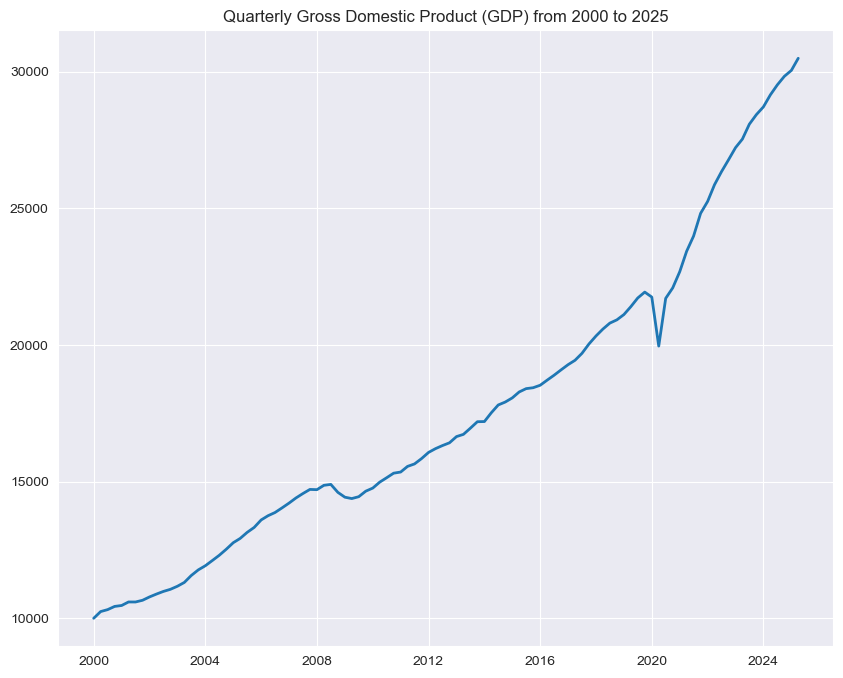

In [152]:
# First we plot the data before interpolation
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(gdp_df.index, gdp_df['GDP'], linewidth=2, markersize=12)
plt.title('Quarterly Gross Domestic Product (GDP) from 2000 to 2025')
plt.show()

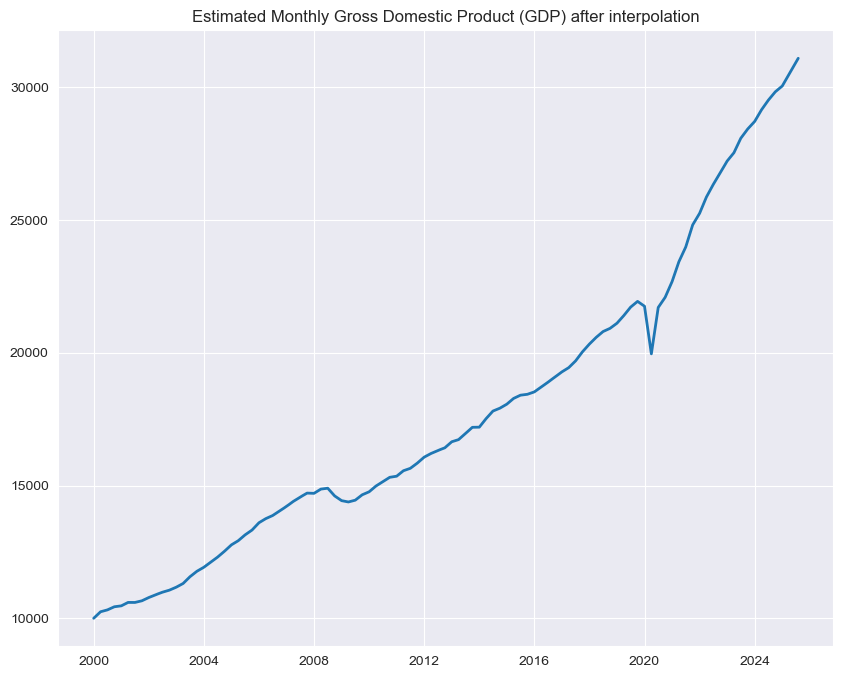

In [153]:
# We extend our current date time into the future
future_dates = pd.to_datetime(['2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01'])
extended_index = gdp_df.index.union(future_dates)

# print(extended_index)
gdp_df = gdp_df.reindex(extended_index)

# Then we interpolate the data 
gdp_df = gdp_df.resample('MS')
gdp_df = gdp_df.interpolate(method='spline', order = 1)

# Check the data after interpolation
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(gdp_df.index, gdp_df['GDP'], linewidth=2, markersize=12)
plt.title('Estimated Monthly Gross Domestic Product (GDP) after interpolation')
plt.show()

### Estimating the monthly Natural Unemployment rate from quarterly rate


We then try to estimate the monthly natural rate of unemployment (NAIRU) data using resampling and interpolation in Python.  


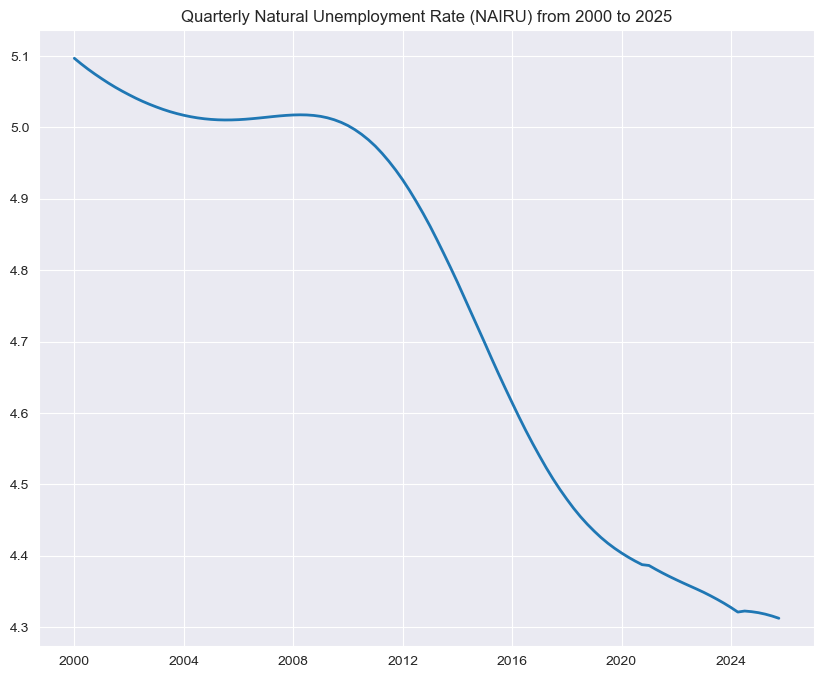

In [154]:
# First we plot the data before interpolation
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(natural_unemp_df.index, natural_unemp_df['NROU'], linewidth=2, markersize=12)
plt.title('Quarterly Natural Unemployment Rate (NAIRU) from 2000 to 2025')
plt.show()

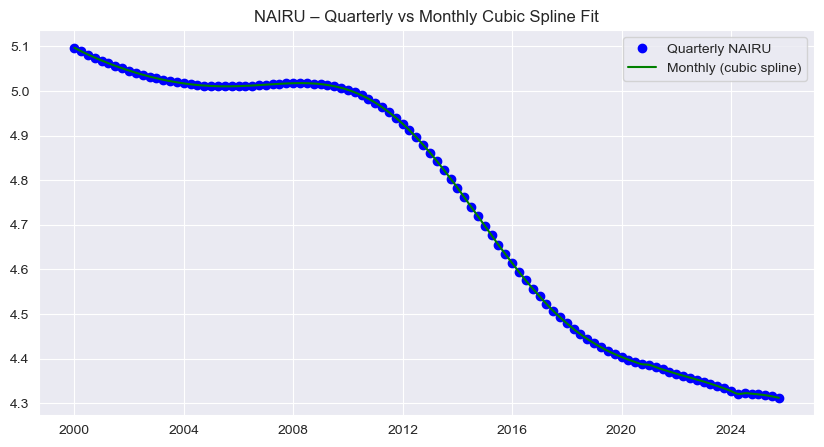

In [155]:
# With the pattern being represented, we use cubic spline interpolation to fit monthly data
# We interpolate the data 
# natural_unemp_df = natural_unemp_df.resample('MS')

# cubic spline with “natural” boundary conditions to reduce edge wiggles
cs = CubicSpline(natural_unemp_df.index.view('int64'), natural_unemp_df['NROU'], bc_type='natural')

# monthly dates from first to last quarter
monthly_natural_unemp_df = natural_unemp_df.resample('MS').first()
x_m = monthly_natural_unemp_df.index.view('int64')

nairu_monthly_cs = pd.DataFrame(cs(x_m), 
        index=monthly_natural_unemp_df.index, 
        columns=['NROU']
)

plt.figure(figsize=(10, 5))
plt.plot(natural_unemp_df.index, natural_unemp_df['NROU'], 'o', color='blue', label='Quarterly NAIRU')
plt.plot(nairu_monthly_cs.index, nairu_monthly_cs['NROU'], color='green', label='Monthly (cubic spline)')
plt.legend()
plt.title('NAIRU – Quarterly vs Monthly Cubic Spline Fit')
plt.show()

natural_unemp_df = nairu_monthly_cs.copy()

## Data Cleaning and Formatting 

In [156]:
print(cpi_df.head(5))
print(unemp_df.head(5))
print(job_df.head(5))
print(sp500_df.head(5))
print(bond_df.head(5))
print(interest_df.head(5))
print(gdp_df.head(5))
print(natural_unemp_df.head(5))

            CPIAUCSL
date                
2000-01-01     169.3
2000-02-01     170.0
2000-03-01     171.0
2000-04-01     170.9
2000-05-01     171.2
            UNRATE
date              
2000-01-01     4.0
2000-02-01     4.1
2000-03-01     4.0
2000-04-01     3.8
2000-05-01     4.0
            JTSJOL
date              
2000-12-01    5088
2001-01-01    5234
2001-02-01    5097
2001-03-01    4762
2001-04-01    4615
                  SPY
date                 
1999-08-01  82.999374
1999-09-01  81.145393
1999-10-01  86.345009
1999-11-01  87.782784
1999-12-01  92.795937
            DGS10
date             
2000-01-01   6.58
2000-02-01   6.62
2000-03-01   6.39
2000-04-01   6.00
2000-05-01   6.29
            FEDFUNDS
date                
2000-01-01      5.45
2000-02-01      5.73
2000-03-01      5.85
2000-04-01      6.02
2000-05-01      6.27
                     GDP
2000-01-01  10002.179000
2000-02-01  10085.816288
2000-03-01  10163.985130
2000-04-01  10247.720000
2000-05-01  10270.876805
          

In [157]:
# Sanity check on the index type
assert (type(job_df.index) == type(sp500_df.index) == type(inflation_df.index)
        == type(cpi_df.index) == type(unemp_df.index)
        == type(gdp_df.index) == type(interest_df.index)
        == type(natural_unemp_df.index) == type(bond_df.index) == pd.DatetimeIndex)


In [158]:
# Count the number of Nan values
print(cpi_df.isna().sum())
print(unemp_df.isna().sum())
print(job_df.isna().sum())
print(sp500_df.isna().sum())
print(interest_df.isna().sum())
print(bond_df.isna().sum())
print(gdp_df.isna().sum())
print(inflation_df.isna().sum())

CPIAUCSL    0
dtype: int64
UNRATE    0
dtype: int64
JTSJOL    0
dtype: int64
SPY    0
dtype: int64
FEDFUNDS    0
dtype: int64
DGS10    0
dtype: int64
GDP    0
dtype: int64
inflation_rate    0
dtype: int64


In [159]:
# Include another Dummy Variables for which Party is winning presidency
dates = pd.date_range(start = "2000-10-01", end = "2025-08-01", freq = "MS")

# Determine the presidency 
def president_party(date):
    if (date < pd.Timestamp("2000-01-20")  # Bill Clinton
            or pd.Timestamp("2009-01-20") < date < pd.Timestamp("2017-01-20") # Obama
            or pd.Timestamp("2021-01-20") < date < pd.Timestamp("2025-01-20")): # Biden
        return "Dem"
    else:
        return "Rep"
    
party_df = pd.DataFrame({
    "date": dates,
    "party": [president_party(d) for d in dates]
})

# Dummy variable: 1 = Republican, 0 = Democrat
party_df["party"] = (party_df["party"] == "Rep").astype(int)
party_df.set_index('date', inplace = True)

In [160]:
print(assault_df.index)

DatetimeIndex(['2000-01-01', '2000-02-01', '2000-03-01', '2000-04-01',
               '2000-05-01', '2000-06-01', '2000-07-01', '2000-08-01',
               '2000-09-01', '2000-10-01',
               ...
               '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01',
               '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-10-01', '2025-11-01'],
              dtype='datetime64[ns]', name='date', length=311, freq=None)


In [161]:
# Join those data together
joined_df = cpi_df.join(unemp_df, how='right')
joined_df = joined_df.join(natural_unemp_df, how='left')
joined_df = joined_df.join(gdp_df, how='left')
joined_df = joined_df.join(job_df, how='right')
joined_df = joined_df.join(inflation_df, how='left')
joined_df = joined_df.join(interest_df, how='left')
joined_df = joined_df.join(bond_df, how='left')
joined_df = joined_df.join(sp500_df, how='inner')
joined_df = joined_df.join(party_df, how='left')
joined_df = joined_df.join(assault_df, how='left')
joined_df = joined_df.join(continuing_jobless_df, how='left')
joined_df = joined_df.join(jobquit_df, how='left')
joined_df = joined_df.join(jobless_df, how='left')
joined_df = joined_df.join(labor_df, how='left')

In [162]:
print(joined_df.columns.tolist())

['CPIAUCSL', 'UNRATE', 'NROU', 'GDP', 'JTSJOL', 'inflation_rate', 'FEDFUNDS', 'DGS10', 'SPY', 'party', 'Crime_count', 'CCSA', 'JTSQUR', 'ICSA', 'PAYEMS']


In [163]:
# Rename column names for easier use 
joined_df.rename(columns={
    'NROU' : 'natural_unemp',
    'CPIAUCSL' : 'cpi',
    'UNRATE' : 'unemp',
    'JTSJOL' : 'job_postings',
    'FEDFUNDS' : 'interest_rate',
    'DGS10' : 'bond',
    'SPY' : 'sp500',
    'Crime_count' : 'crime',
    'CSCICP03USM665S' : 'consumer_conf',
    'CCSA' : 'continued_claims',
    'JTSQUR' : 'quit',
    'ICSA' : 'initial_claims',
    'PAYEMS' : 'labor participation'
}, inplace=True)

In [164]:
# Create a new dummy variable for when unemployment rate is above natural rate of unemloyment
joined_df['unemp_higher_than_natural'] = np.where(
    joined_df['unemp'] > joined_df['natural_unemp'],
    1, 0)

## Exploratory Data Analysis

We then examine our datasets before building our machine learning model 

In [165]:
joined_df.head(5)

,cpi,unemp,natural_unemp,GDP,job_postings,inflation_rate,interest_rate,bond,sp500,party,crime,continued_claims,quit,initial_claims,labor participation,unemp_higher_than_natural
date,,,,,,,,,,,,,,,,
2000-12-01,174.6,3.9,5.070404,10458.684220,5088,0.229621,6.40,5.52,83.756271,1,143636,11532000,2.2,1730000,132716,0
2001-01-01,175.6,4.2,5.068230,10470.231000,5234,0.572738,5.98,4.92,87.480011,1,56365,9583000,2.4,1360000,132703,0
2001-02-01,176.0,4.2,5.066076,10514.637779,5097,0.227790,5.49,5.10,79.135498,1,50725,9946000,2.3,1485000,132788,0
2001-03-01,176.1,4.3,5.064155,10554.585284,4762,0.056818,5.31,4.87,74.700928,1,61147,12927000,2.3,1936000,132751,0
2001-04-01,176.4,4.4,5.062071,10599.000000,4615,0.170358,4.80,4.98,81.083435,1,64005,10789000,2.4,1587000,132457,0


In [166]:
joined_df.tail(5)

,cpi,unemp,natural_unemp,GDP,job_postings,inflation_rate,interest_rate,bond,sp500,party,crime,continued_claims,quit,initial_claims,labor participation,unemp_higher_than_natural
date,,,,,,,,,,,,,,,,
2025-04-01,320.321,4.2,4.318228,30485.729000,7395,0.220891,4.33,4.17,551.376831,1,61072,7491000,2.0,904000,159433,0
2025-05-01,320.580,4.2,4.317423,30633.378449,7712,0.080856,4.33,4.25,586.028015,1,64548,9530000,2.0,1170000,159452,0
2025-06-01,321.500,4.1,4.316535,30786.057742,7357,0.286980,4.33,4.46,616.141785,1,63112,7811000,2.0,965000,159439,0
2025-07-01,322.132,4.2,4.315608,30933.811896,7208,0.196579,4.33,4.26,630.332458,1,63738,7801000,2.0,885000,159511,0
2025-08-01,323.364,4.3,4.314575,31086.491188,7227,0.382452,4.33,4.23,643.266602,1,58108,9713000,1.9,1150000,159507,0


In [167]:
# Count the number of Nan values
print(joined_df.isna().sum())

cpi                          0
unemp                        0
natural_unemp                0
GDP                          0
job_postings                 0
inflation_rate               0
interest_rate                0
bond                         0
sp500                        0
party                        0
crime                        0
continued_claims             0
quit                         0
initial_claims               0
labor participation          0
unemp_higher_than_natural    0
dtype: int64


In [168]:
# Total number of observations and date range
print(f'Total number of observations is {len(joined_df)}')
print(joined_df.columns.tolist())
joined_df.shape

Total number of observations is 297
['cpi', 'unemp', 'natural_unemp', 'GDP', 'job_postings', 'inflation_rate', 'interest_rate', 'bond', 'sp500', 'party', 'crime', 'continued_claims', 'quit', 'initial_claims', 'labor participation', 'unemp_higher_than_natural']


(297, 16)

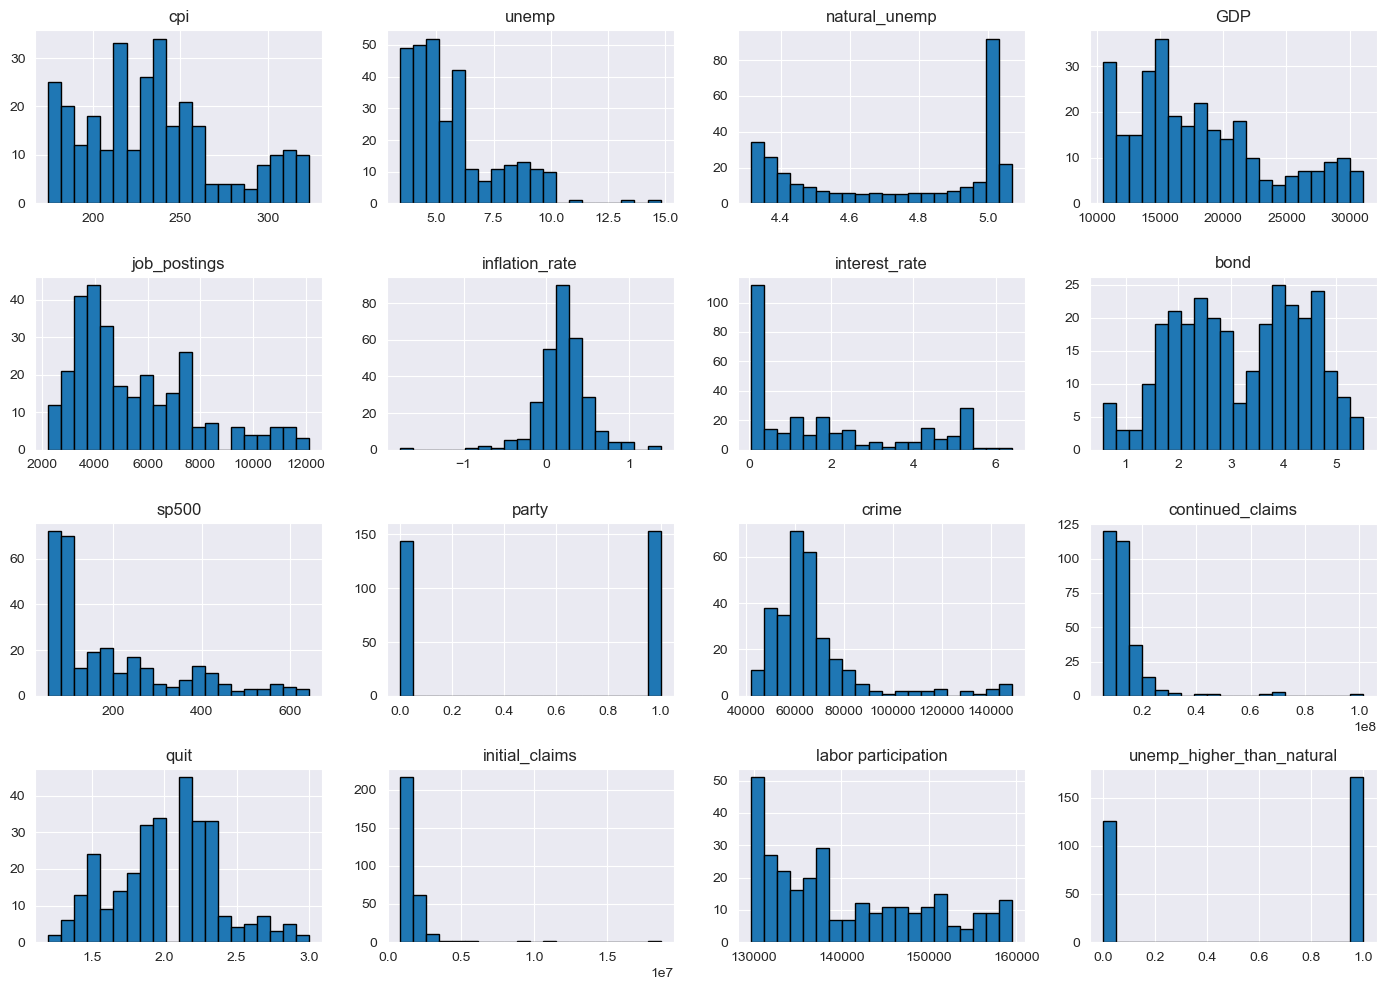

In [169]:
joined_df.hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.tight_layout()
plt.show()

Sources: Job Postings (in thousands) - From the Bureau of Labor Statistics  
Bonds prices taken from Vanguard's BND which focus on wide spectrum of bonds - Yahoo Finance  
Federal Fund Rate (the rate at which banks with each other at the end of night) - Federal Reserve Bank of ST.LOUIS  
CPI, Unemployment rate, S&P 500 - Federal Reserve Bank of ST.LOUIS

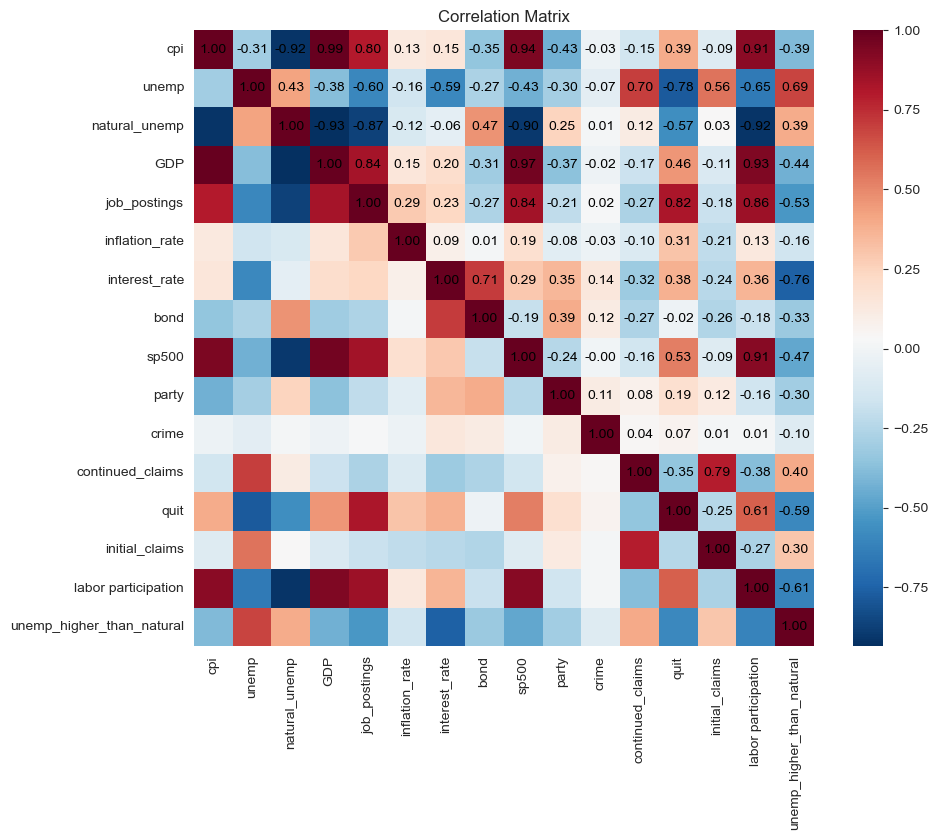

In [170]:
# Explore the correlation between variables
corr_mat = joined_df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, cmap='RdBu_r', ax=ax, cbar=True)

for i in range(corr_mat.shape[0]):
    for j in range(i, corr_mat.shape[1]): # upper triangle only
        val = corr_mat.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{val:.2f}",
                ha="center", va="center", color="black")

ax.set_title("Correlation Matrix")
plt.savefig("Visualizations/Without_TS/CorrMat.png", dpi=300, bbox_inches="tight")
plt.show()

Interestingly, GDP and CPI has the correlation of 1.  
We can also see that GDP and S&P500 has high correlation of 0.98, CPI and S&P500 has high correlation of 0.97  
GDP and job postings also has correlation up to 0.84

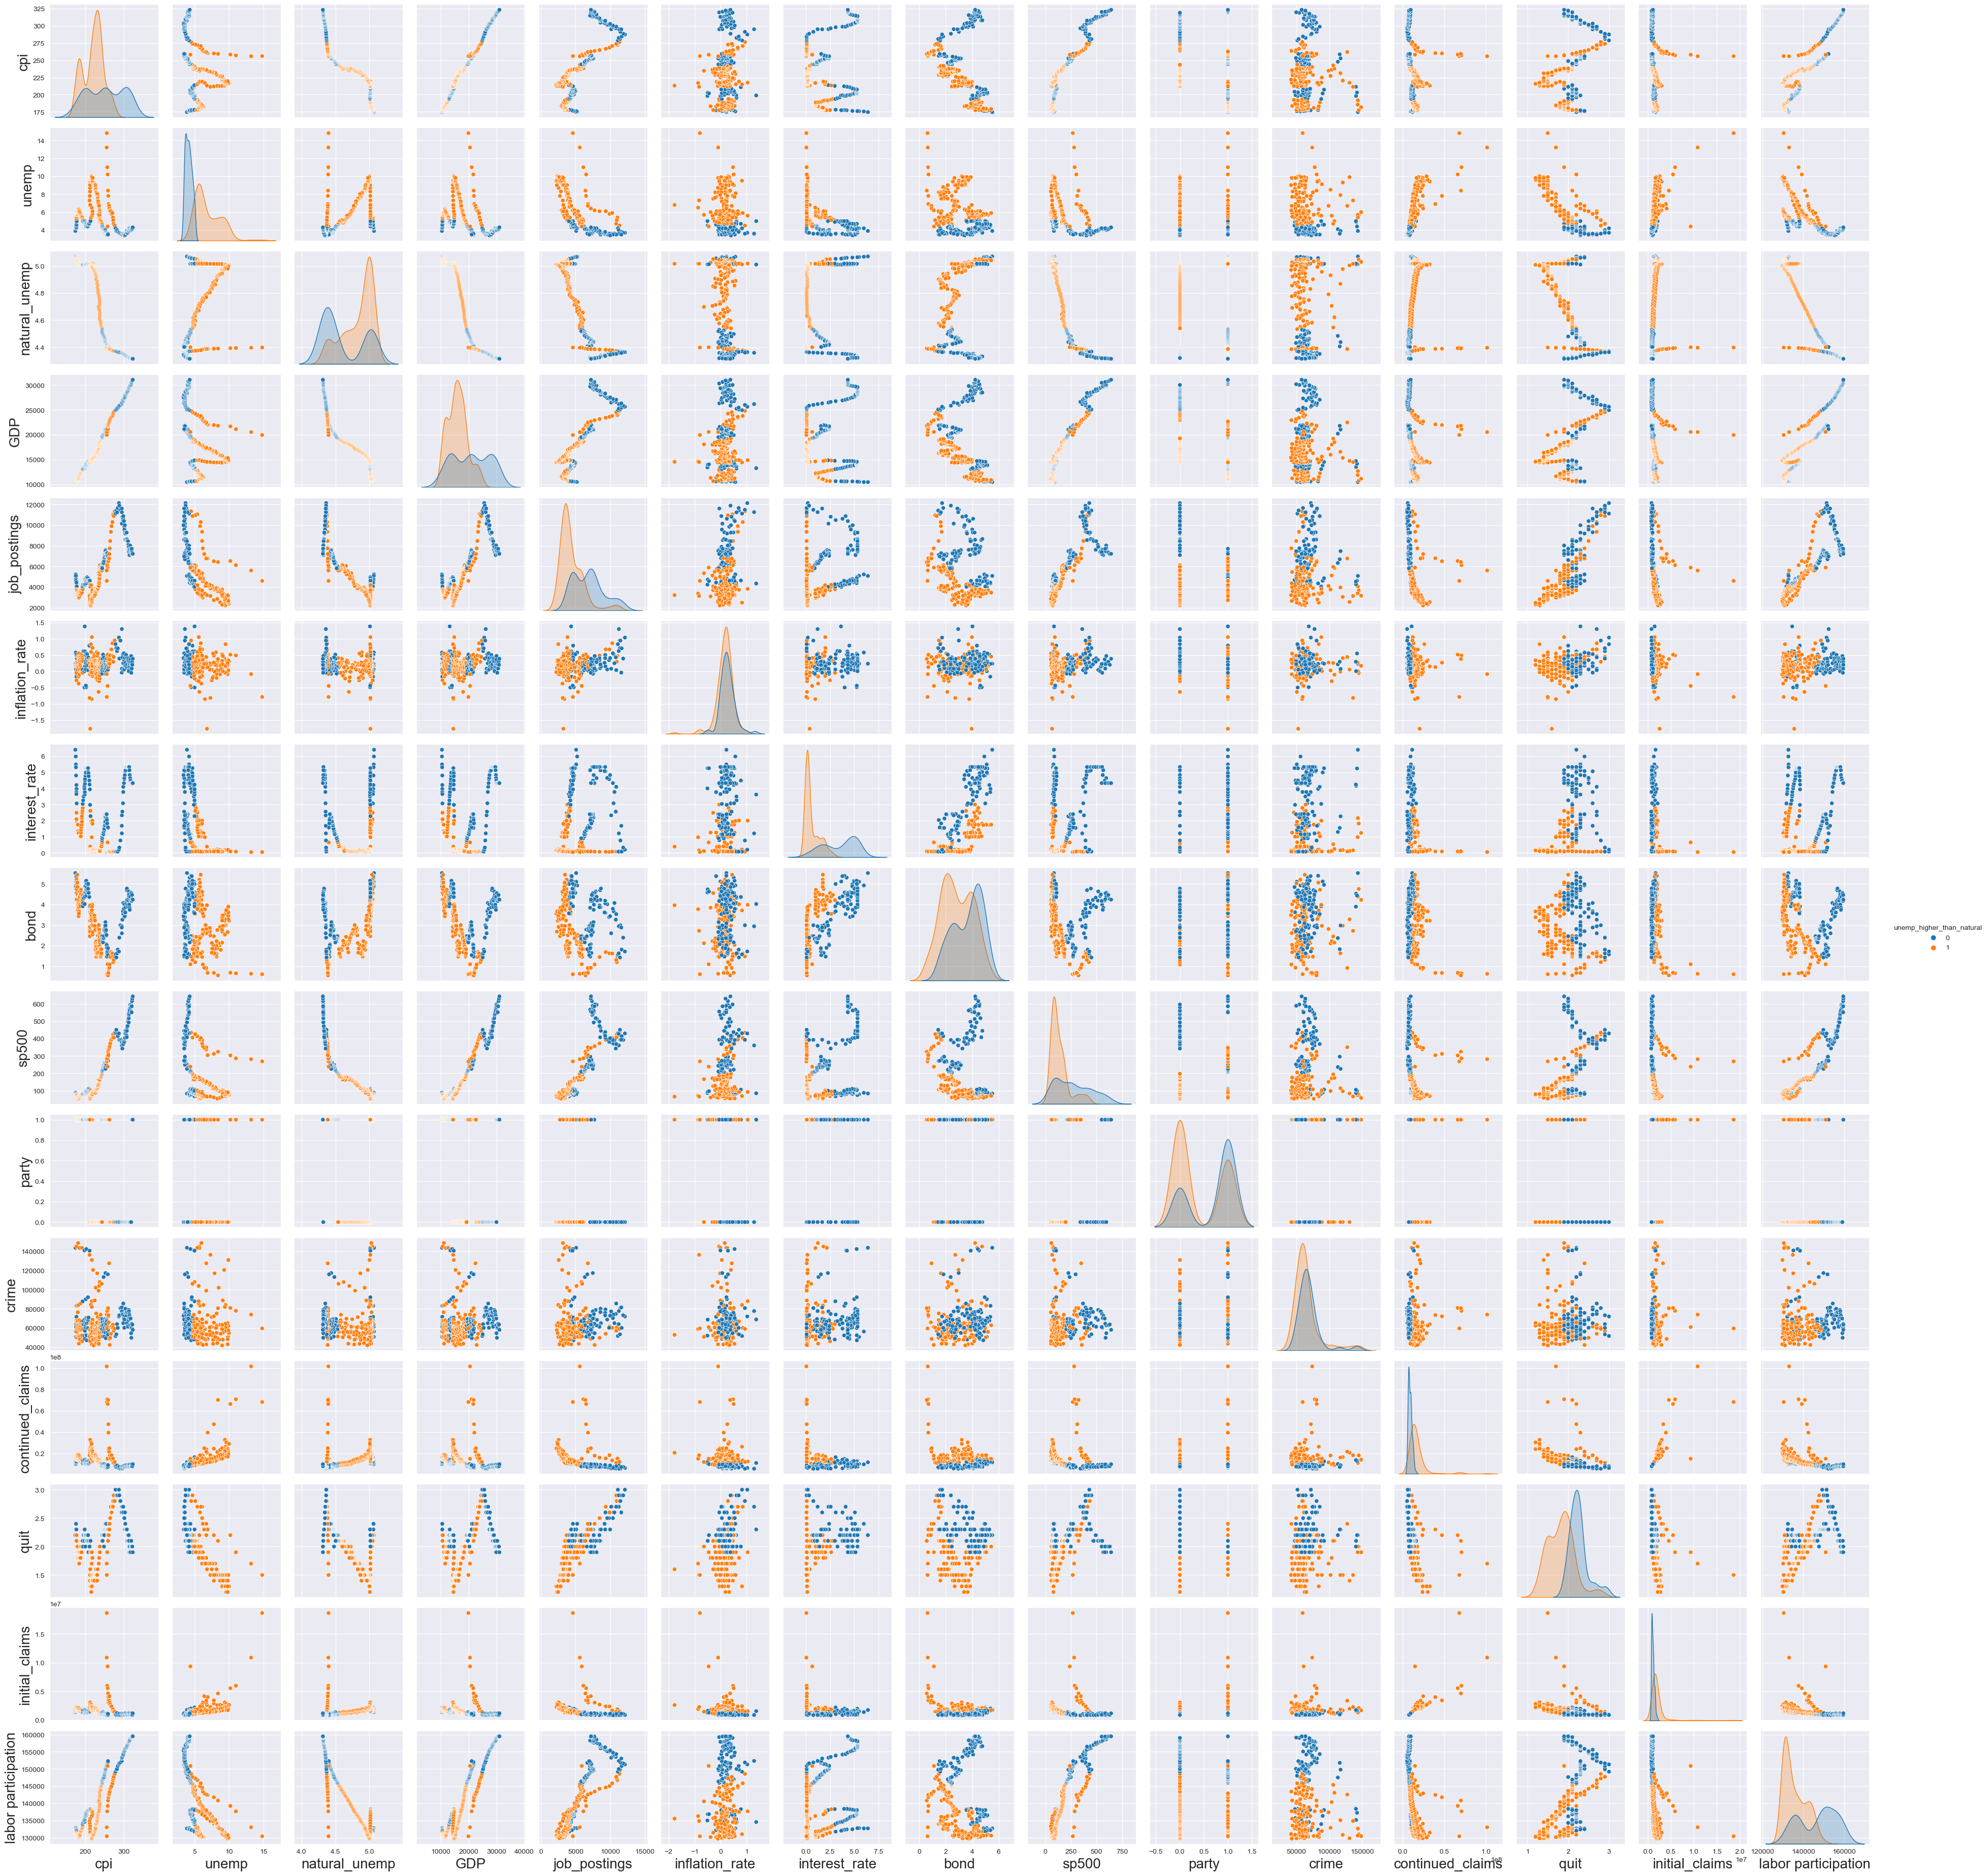

In [171]:
# Pairplots representing the relationships between variables
g = sns.pairplot(joined_df, hue = 'unemp_higher_than_natural')
# Blue for lower, Orange for higher
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.savefig("Visualizations/Without_TS/PairsPlot.png", dpi=300, bbox_inches="tight")
plt.show()

As we can see, the relationship between variables are not linear apart from pairs that have high correlation like CPI and GDP,  
and GDP and SP500

## Fitting Models

Since we can see that not all relationship of variables with Unemployment are linear  
and we want to interpret the relationship between Job Postings and Unemployment here  
So we can try Generalized Additive Models before fitting more complex non-parametric methods

### Adjustments for Multicollinearity and Add Time Adjustments

We realized from our pairs plot and correlation matrix that some predictors are highly correlated i.e. GDP and CPI, GDP and SP500

In [172]:
new_df = joined_df.drop(["unemp_higher_than_natural", "unemp", "natural_unemp"], axis=1)
corr_mat = new_df.corr()

eigvals, eigvecs = np.linalg.eig(corr_mat)

# Sort by largest eigenvalue
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Keep proper feature names
eigvals = pd.Series(eigvals, name="eigenvalue")
eigvecs = pd.DataFrame(
    eigvecs,
    index= new_df.columns,
    columns=[f"eigvec_{i}" for i in range(len(eigvals))]
)

In [173]:
# Calculate Ratio = max eigenvalue / all eigenvalues
ratio = eigvals.iloc[0] / eigvals
# Identify which element of the ratio vector is highest
k = ratio.idxmax()     # eigenvector index with highest ratio
print("Index of dominant eigenvector:", k)
print("Highest ratio:", ratio[k])

# Look at the corresponding vector
dominant_vec = eigvecs[f"eigvec_{k}"]
dominant_vec

Index of dominant eigenvector: 12
Highest ratio: 6094.245629306


cpi                   -0.595126
GDP                    0.789007
job_postings          -0.004627
inflation_rate         0.004120
interest_rate          0.001253
bond                   0.002107
sp500                 -0.138789
party                 -0.006567
crime                 -0.001251
continued_claims      -0.013494
quit                  -0.023704
initial_claims         0.012793
labor participation   -0.055084
Name: eigvec_12, dtype: float64

In [174]:
# Identify the two largest elements
top2 = dominant_vec.abs().nlargest(2)
print("Most collinear variables:\n")
print(top2)

Most collinear variables:

GDP    0.789007
cpi    0.595126
Name: eigvec_12, dtype: float64


**This means that CPI and GDP are sources of multicollinearity**  
This reference is consistent with our analysis of the pairs plot and correlation matrix

### Split Train and Test dataset

In [175]:
joined_df.drop(top2.index.tolist(), axis = 1, inplace=True) # Drop the CPI and GDP
dropped = joined_df.drop(['unemp_higher_than_natural', 'natural_unemp'], axis = 1)
predictor_columns = dropped.drop(['unemp'], axis=1).columns.tolist()

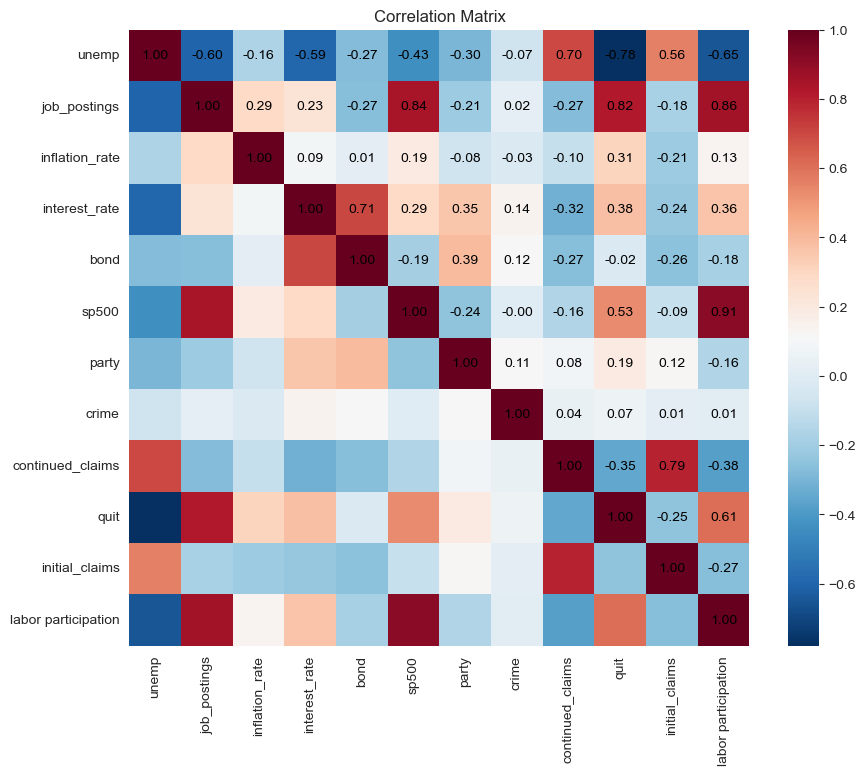

In [176]:
corr_mat = dropped.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, cmap='RdBu_r', ax=ax, cbar=True)

for i in range(corr_mat.shape[0]):
    for j in range(i, corr_mat.shape[1]): # upper triangle only
        val = corr_mat.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{val:.2f}",
                ha="center", va="center", color="black")

ax.set_title("Correlation Matrix")
plt.savefig("Visualizations/Without_TS/Dropped_CorrMat.png", dpi=300, bbox_inches="tight")
plt.show()

In [177]:
train_X, test_X, train_Y, test_Y = skm.train_test_split(dropped.drop(['unemp'], axis=1), dropped['unemp'])
print(train_X.shape)
print(test_X.shape)
print(np.isnan(train_X).sum(axis=0))
print(np.isnan(test_X).sum(axis=0))

(222, 11)
(75, 11)
job_postings           0
inflation_rate         0
interest_rate          0
bond                   0
sp500                  0
party                  0
crime                  0
continued_claims       0
quit                   0
initial_claims         0
labor participation    0
dtype: int64
job_postings           0
inflation_rate         0
interest_rate          0
bond                   0
sp500                  0
party                  0
crime                  0
continued_claims       0
quit                   0
initial_claims         0
labor participation    0
dtype: int64


In [178]:
print(train_Y.shape)
print(test_Y.shape)

(222,)
(75,)


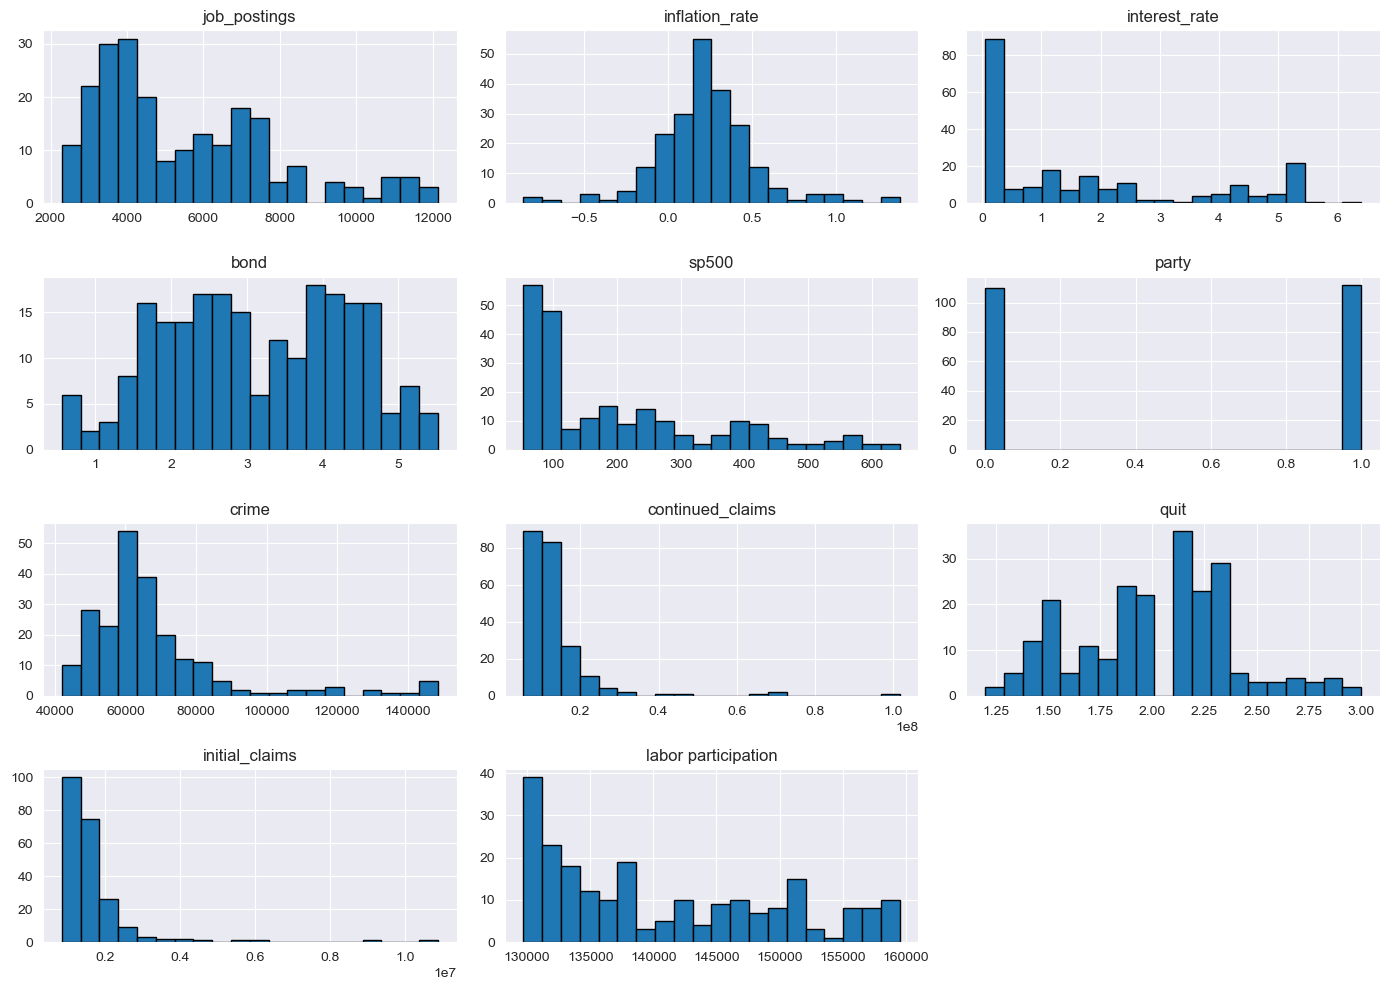

In [179]:
train_X.hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.tight_layout()
plt.show()

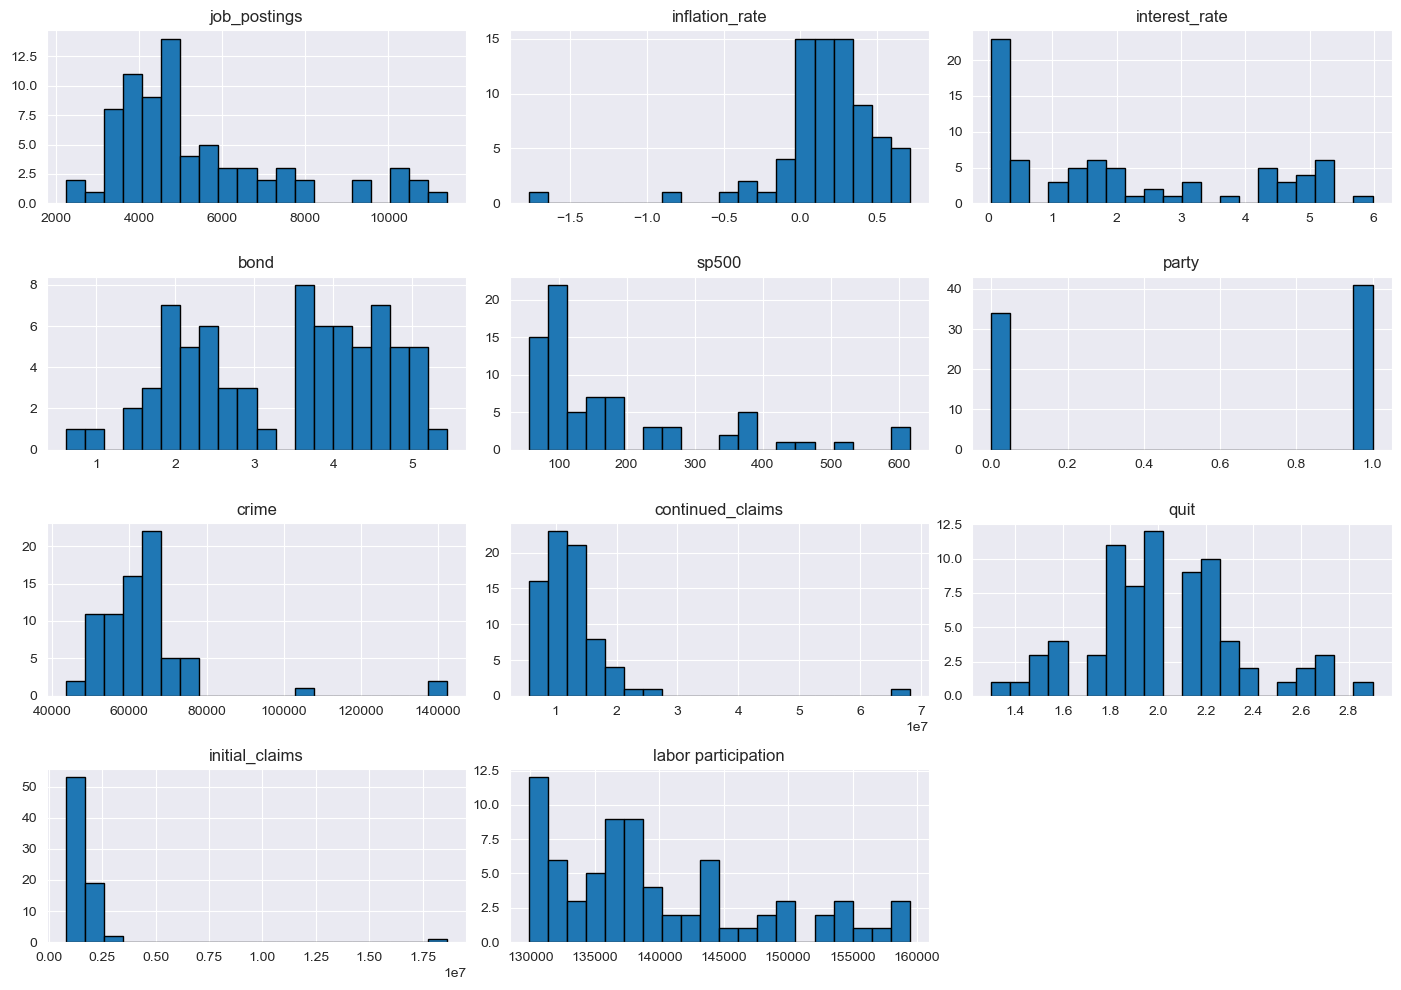

In [180]:
test_X.hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.tight_layout()
plt.show()

### Standardization

In [181]:
# Scale X
cols_to_scale = train_X.drop(['party'], axis=1).columns.tolist()

train_X_scaled = train_X.copy()
test_X_scaled = test_X.copy()

# x = (z - mean) / sd 

scaler = StandardScaler()
scaler.fit(train_X[cols_to_scale])
train_X_scaled[cols_to_scale] = scaler.transform(train_X_scaled[cols_to_scale])
test_X_scaled[cols_to_scale] = scaler.transform(test_X_scaled[cols_to_scale])

print(train_X_scaled.shape)
print(test_X_scaled.shape)

(222, 11)
(75, 11)


In [182]:
y_scaler = StandardScaler()
y_scaler.fit(train_Y.values.reshape(-1, 1))

train_Y_scaled = y_scaler.transform(train_Y.values.reshape(-1, 1)).ravel()
test_Y_scaled  = y_scaler.transform(test_Y.values.reshape(-1, 1)).ravel()

### Multiple Linear Regression + Ridge + Lasso

In [183]:
def evaluate_linear_model(model, train_X, train_Y, test_X, test_Y):
    """
    Evaluate a regression model with:
      - Cross-validated RMSE, MAE, R²
      - Train vs Test RMSE
    """

    # ----- Choose CV strategy -----
    cv = skm.TimeSeriesSplit(n_splits=5)

    # ----- Cross-validated RMSE -----
    cv_mse_scores = skm.cross_val_score(
        model, train_X, train_Y,
        cv=cv, scoring="neg_mean_squared_error"
    )
    cv_rmse = np.sqrt(-cv_mse_scores.mean())

    # ----- Cross-validated R² -----
    cv_r2_scores = skm.cross_val_score(
        model,  train_X, train_Y,
        cv=cv, scoring="r2"
    )
    cv_r2 = cv_r2_scores.mean()

    # ----- Fit on full train, compute Train/Test RMSE -----
    model.fit( train_X, train_Y)

    y_train_pred = model.predict(train_X)
    y_test_pred  = model.predict(test_X)

    train_rmse = np.sqrt(root_mean_squared_error(train_Y, y_train_pred))
    test_rmse  = np.sqrt(root_mean_squared_error(test_Y, y_test_pred))

    results = {
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
    }

    print("=== Cross-Validation Metrics ===")
    print(f"CV RMSE : {cv_rmse:.4f}")
    print(f"CV R²   : {cv_r2:.4f}")
    print()
    print("=== Train/Test RMSE ===")
    print(f"Train RMSE : {train_rmse:.4f}")
    print(f"Test RMSE  : {test_rmse:.4f}")


### Multiple Linear Regression

In [184]:
X_train = sm.add_constant(train_X_scaled)
X_test = sm.add_constant(test_X_scaled)

model = sm.OLS(train_Y_scaled, X_train).fit()

pred_test = model.predict(X_test)
print(model.summary(), '\n')

pred_train = model.predict(X_train)
mse_train = root_mean_squared_error(train_Y_scaled, pred_train)
mse_test = root_mean_squared_error(test_Y_scaled, pred_test)

print("Train RMSE:", mse_train)
print("Test RMSE:", mse_test)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     380.4
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          4.52e-132
Time:                        16:03:21   Log-Likelihood:                 22.557
No. Observations:                 222   AIC:                            -21.11
Df Residuals:                     210   BIC:                             19.72
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.1352    

In [185]:
cv = skm.TimeSeriesSplit(n_splits=5)
ridge = skl.RidgeCV(fit_intercept=True, cv=5).fit(train_X_scaled, train_Y_scaled)
coef_ridge_df = pd.DataFrame({
    'columns' : predictor_columns,
    'coefficient': ridge.coef_
})
print(coef_ridge_df, "\n")
evaluate_linear_model(ridge, train_X_scaled, train_Y_scaled,
                             test_X_scaled,  test_Y_scaled)

                columns  coefficient
0          job_postings     0.237053
1        inflation_rate     0.015957
2         interest_rate    -0.034675
3                  bond    -0.129258
4                 sp500     0.290275
5                 party    -0.271628
6                 crime    -0.006404
7      continued_claims     0.324969
8                  quit    -0.575488
9        initial_claims    -0.028760
10  labor participation    -0.708199 

=== Cross-Validation Metrics ===
CV RMSE : 0.2455
CV R²   : 0.9339

=== Train/Test RMSE ===
Train RMSE : 0.4675
Test RMSE  : 0.5559


In [186]:
lasso = skl.LassoCV(fit_intercept=True, cv=5,
                    random_state=0, max_iter=10000).fit(train_X_scaled, train_Y_scaled)
coef_lasso_df = pd.DataFrame({
    'columns' : predictor_columns,
    'coefficient': lasso.coef_
})
print(coef_lasso_df, "\n")
evaluate_linear_model(lasso, train_X_scaled, train_Y_scaled,
                             test_X_scaled,  test_Y_scaled)

                columns  coefficient
0          job_postings     0.220325
1        inflation_rate     0.016650
2         interest_rate    -0.037950
3                  bond    -0.126145
4                 sp500     0.284944
5                 party    -0.279390
6                 crime    -0.005559
7      continued_claims     0.324048
8                  quit    -0.564672
9        initial_claims    -0.023662
10  labor participation    -0.692688 

=== Cross-Validation Metrics ===
CV RMSE : 0.2497
CV R²   : 0.9322

=== Train/Test RMSE ===
Train RMSE : 0.4677
Test RMSE  : 0.5537


## Classification Problem

We then transform the problem to classify when unemployment rate is below or above natural employment rate here

In [187]:
print(train_X.columns.tolist())

['job_postings', 'inflation_rate', 'interest_rate', 'bond', 'sp500', 'party', 'crime', 'continued_claims', 'quit', 'initial_claims', 'labor participation']


In [188]:
def metrics_printer(models : dict(), train_X, train_Y, test_X, test_Y) -> pd.DataFrame:
    results = []   # list of rows for DF

    for name, model in models.items():

        # Predictions
        y_pred_train = model.predict(train_X)
        y_pred_test  = model.predict(test_X)

        # Metrics
        train_acc = accuracy_score(train_Y, y_pred_train)
        test_acc  = accuracy_score(test_Y, y_pred_test)
        prec      = precision_score(test_Y, y_pred_test, zero_division=0)
        rec       = recall_score(test_Y, y_pred_test, zero_division=0)
        f1        = f1_score(test_Y, y_pred_test, zero_division=0)
        auc       = roc_auc_score(test_Y, y_pred_test)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(test_Y, y_pred_test).ravel()

        # OOB score (only for RF)
        oob = model.oob_score_ if hasattr(model, "oob_score_") else None

        # Add row
        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "AUC": auc,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "OOB Score": oob
        })

    # Convert to DataFrame
    res_df = pd.DataFrame(results)
    return res_df

In [189]:
svm_train_X = train_X_scaled.drop(['party'], axis=1).copy()
svm_test_X = test_X_scaled.drop(['party'], axis=1).copy()
unemp_higher_df = (joined_df['unemp_higher_than_natural']).to_frame()
unemp_higher_train = unemp_higher_df.join(train_X, how='right')
unemp_higher_test = unemp_higher_df.join(test_X, how='right')
train_Y = unemp_higher_train['unemp_higher_than_natural']
test_Y = unemp_higher_test['unemp_higher_than_natural']
print(svm_train_X.columns.tolist())
print(test_X.shape)
print(test_Y.shape)

['job_postings', 'inflation_rate', 'interest_rate', 'bond', 'sp500', 'crime', 'continued_claims', 'quit', 'initial_claims', 'labor participation']
(75, 11)
(75,)


In [190]:
train_count = train_Y.value_counts()
test_count = test_Y.value_counts()
print(train_count)
print(test_count)

unemp_higher_than_natural
1    128
0     94
Name: count, dtype: int64
unemp_higher_than_natural
1    43
0    32
Name: count, dtype: int64


In [191]:
costs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
gammas = ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1]
# cv = skm.TimeSeriesSplit(n_splits=5)

### Logistic Regression

In [192]:
# Logistics Regression
logreg = skl.LogisticRegression(
    penalty='l2',            # ridge-like
    solver='liblinear',
    class_weight='balanced',
    max_iter=500
)

logreg.fit(svm_train_X, train_Y)
coef = logreg.coef_[0]   # for binary classification
intercept = logreg.intercept_[0]

coef_df = pd.DataFrame({
    "feature": svm_train_X.columns,
    "coefficient": coef
})

print("Intercept:", intercept)
print(coef_df)

Intercept: 0.4990115080080382
               feature  coefficient
0         job_postings    -0.149830
1       inflation_rate     0.131448
2        interest_rate    -2.995406
3                 bond    -0.619908
4                sp500    -0.294416
5                crime    -0.075427
6     continued_claims     1.030102
7                 quit    -0.511763
8       initial_claims     0.972343
9  labor participation    -2.459987


### Support Vector Machine (Linear or Radial)

In [193]:
svm_linear = SVC(kernel='linear', class_weight='balanced', probability=True)
grid_svm_linear = skm.GridSearchCV(svm_linear, 
                        {'C': costs,
                         'gamma': gammas},
                        refit = True,
                        cv = 5,
                        scoring = 'f1')
grid_svm_linear.fit(svm_train_X, train_Y)

,estimator,SVC(class_wei...bability=True)
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto', ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [194]:
svm_radial = SVC(kernel='rbf', class_weight='balanced', probability=True)
grid_svm_radial = skm.GridSearchCV(svm_radial, 
                        { 'C': costs,
                        'gamma': gammas},
                        refit = True,
                        cv = 5,
                        scoring = 'f1')
grid_svm_radial.fit(svm_train_X, train_Y)

,estimator,SVC(class_wei...bability=True)
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto', ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


### Linear Discriminant and Naive Bayes

In [195]:
lda_clf = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
naive_bayes = GaussianNB(priors=[0.5, 0.5])
lda_clf.fit(svm_train_X, train_Y)
naive_bayes.fit(svm_train_X, train_Y)

,priors,"[0.5, 0.5]"
,var_smoothing,1e-09


### Results

In [196]:
models = {
    "Logistics Regression": logreg,
    "Linear Discriminant Analysis" : lda_clf,
    "Naive Bayes" : naive_bayes,
    "Linear SVM": grid_svm_linear,
    "RBF SVM": grid_svm_radial
}

performance = metrics_printer(models, svm_train_X, train_Y,
                              svm_test_X, test_Y)
performance

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,AUC,TN,FP,FN,TP,OOB Score
0,Logistics Regression,0.981982,0.986667,0.977273,1.000000,0.988506,0.984375,31,1,0,43,None
1,Linear Discriminant Analysis,0.977477,0.933333,0.952381,0.930233,0.941176,0.933866,30,2,3,40,None
2,Naive Bayes,0.914414,0.906667,0.973684,0.860465,0.913580,0.914608,31,1,6,37,None
3,Linear SVM,0.981982,0.973333,0.955556,1.000000,0.977273,0.968750,30,2,0,43,None
4,RBF SVM,0.986486,0.973333,0.955556,1.000000,0.977273,0.968750,30,2,0,43,None


## Random Forests and Gradient Boosting Classifier

In [197]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 400, 500], # number of trees
    "max_depth": [1, 2, 3, 4], # depth of each tree
    "min_samples_leaf": [1, 2, 4, 8], # minimum number of samples within each leaf node 
}

# Because classes are imbalanced and we care about both precision + recall:
grid_rf = skm.GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="f1", # maintain a balance between precision and recall
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(train_X, train_Y)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [198]:
print("Best params:", grid_rf.best_params_)
print("Best CV f1:", grid_rf.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV f1: 0.9841568627450981


In [199]:
boost_base = GradientBoostingClassifier(
    n_estimators=300,
    random_state=42,)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [1, 2, 3, 4],
    "min_samples_leaf": [1, 2, 4, 8] # Minimum amount of samples in a leaf node
}

# Because classes are a bit imbalanced and you care about both precision + recall:
grid_boost = skm.GridSearchCV(
    estimator=boost_base,
    param_grid=param_grid,
    scoring="f1",        # or "f1_macro" / "roc_auc"
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_boost.fit(train_X, train_Y)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.001, 0.01, ...], 'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [200]:
print("Best params:", grid_boost.best_params_)
print("Best CV f1:", grid_boost.best_score_)

Best params: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 8, 'n_estimators': 500}
Best CV f1: 0.988078431372549


In [201]:
models = {
    "Random Forest": grid_rf,
    "Gradient Boosting": grid_boost
}

metrics_printer(models, train_X, train_Y, test_X, test_Y)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,AUC,TN,FP,FN,TP,OOB Score
0,Random Forest,0.995495,0.986667,0.977273,1.0,0.988506,0.984375,31,1,0,43,None
1,Gradient Boosting,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,32,0,0,43,None


## Visualization of a simpler Classifier

In [202]:
print(train_X_scaled.columns.tolist())

['job_postings', 'inflation_rate', 'interest_rate', 'bond', 'sp500', 'party', 'crime', 'continued_claims', 'quit', 'initial_claims', 'labor participation']


In [203]:
plot_X = train_X_scaled[['job_postings', 'crime']].to_numpy()
plot_Y = train_Y.to_numpy().ravel()
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

In [204]:
logreg = skl.LogisticRegression(
    penalty='l2',            # ridge-like
    solver='liblinear',
    class_weight='balanced',
    max_iter=500
)

logreg.fit(plot_X, plot_Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [205]:
svm_linear = skm.GridSearchCV(
    LinearSVC(),
    {'C': [0.1, 1, 10, 100]},
    cv = cv
)

svm_linear.fit(plot_X, plot_Y)
print(svm_linear.best_params_)

{'C': 0.1}


In [206]:
# svm_rbf = skm.GridSearchCV(
#     SVC(kernel='rbf'),
#     param_grid,
#     cv = cv
# )
#
# svm_rbf.fit(plot_X, plot_Y)
# print(svm_rbf.best_params_)

In [207]:
rf_clf = skm.GridSearchCV(
    RandomForestClassifier(),
    param_grid = {
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_leaf": [1, 2, 4, 6]
    },
    cv = 5
)

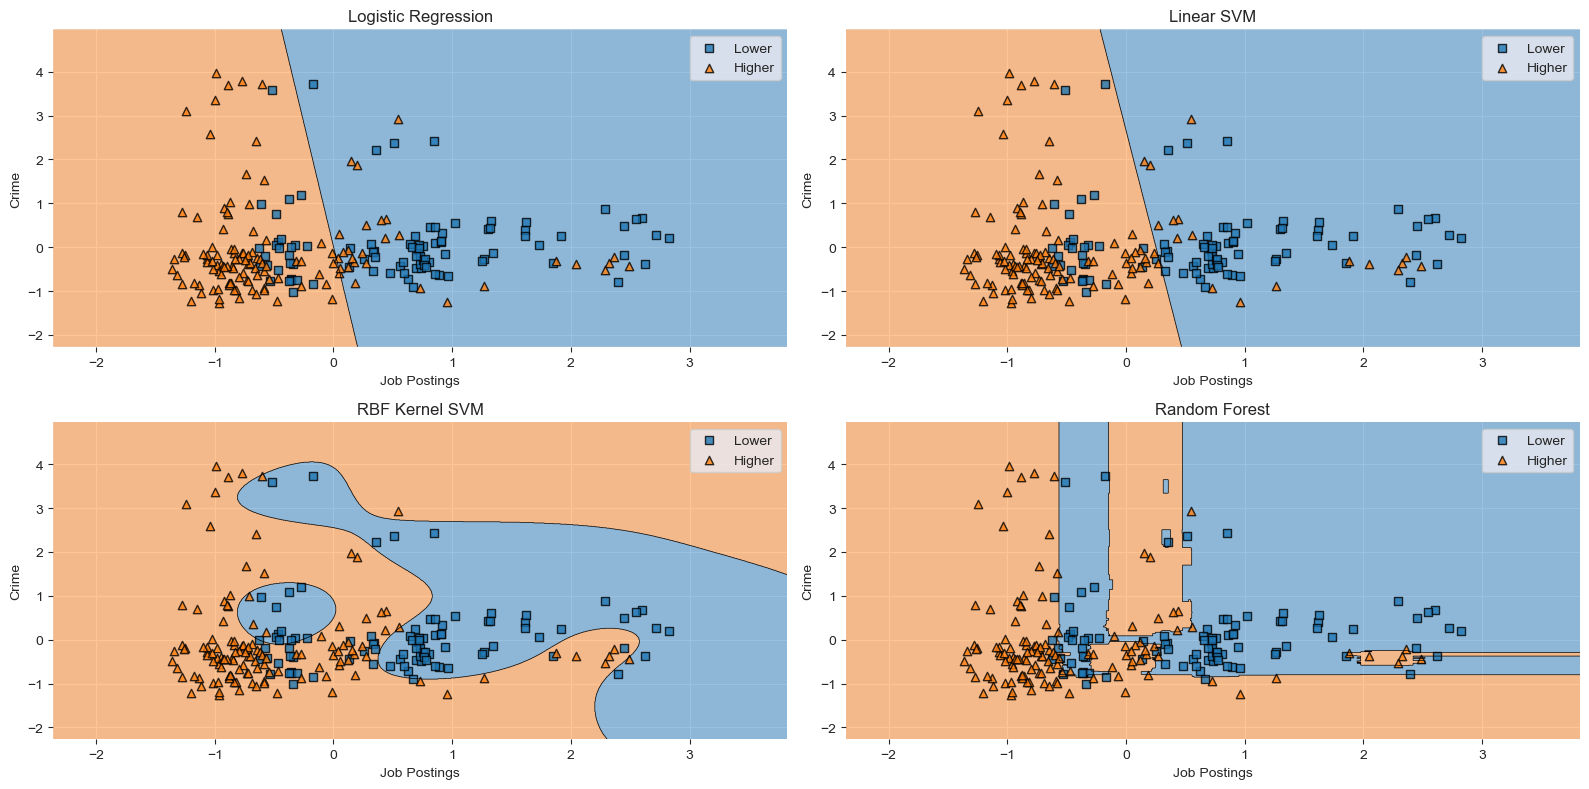

In [208]:
clf_linear = LinearSVC(C = svm_linear.best_params_['C'])
clf_radial = SVC(kernel='rbf', gamma = 'scale', C = 100) 
# For illustration purpose of the radial kernel (we are intentionally modifying the Costs)

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(16,8))
labels = ['Logistic Regression', 'Linear SVM', 'RBF Kernel SVM', 'Random Forest']

for clf, lab, grd in zip([logreg, clf_linear, clf_radial, rf_clf],
                         labels, [(0, 0), (0, 1), (1, 0), (1, 1)]):
    clf.fit(plot_X, plot_Y)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=plot_X, y=plot_Y,
                                clf=clf, legend=2)
    plt.title(lab)
    plt.xlabel('Job Postings')
    plt.ylabel('Crime')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles,
              ['Lower', 'Higher'],   # put your names here
              fontsize=10,
              frameon=True)
    plt.title(lab)
plt.tight_layout()
plt.savefig('Visualizations/Without_TS/Classifier_visualization.png', dpi=300, bbox_inches="tight")
plt.show()